Building likelihood maps for a set of representative images.

> TODO: use images from dataset and superimpose the bounding boxes on them

In [1]:
from retinotopy import *

Running on GPU :  NVIDIA GeForce RTX 3060 #GPU= 1
---------------------------------------------------------------------------------------------------
On date 2024-05-24, Running learning on host DESKTOP-27VNO0E with device cuda, pytorch==2.2.0+cu121
---------------------------------------------------------------------------------------------------
Welcome on Linux-5.10.16.3-microsoft-standard-WSL2-x86_64-with-glibc2.35
Random seed 1998 has been set.


In [2]:
# The dataset to import images from

data_set_type = 'full'
args = Params()
args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
args.folders = ['val'] # type of images to use

args.do_saccade = True
args.do_resize = False
args.do_mask = False

## doing the computations

In [3]:
pos_pred_zero = ((args.resolution[0]*args.resolution[1])//2)

for model_data_set_type in data_set_types:
    print(50*'=')
    print(f'{model_data_set_type=}')    
    
    for model_name in  ['resnet18', 'resnet50', 'resnet101']:
        print(50*'.')
        model = {}
        
        for do_polar in [False, True]:

            args.do_polar = do_polar
            print(f'{args.do_polar=}')

            image_datasets = image_datasets_transforms(args, shuffle=False, verbose=False)
            
            print(50*'.')
            
            model_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + '.pt'
            
            model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()

            annotations = get_annotation('csv')

            df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, do_polar) + f'_complete_heat_map.parquet'
            print(df_filename)
            df_map = None
            
            with torch.no_grad():
                
                for i_image, (images, label) in tqdm(enumerate(image_datasets)):
                    since = time.time()
            
                    images = images.to(device, non_blocking=True)
                    
                    heat_map = model(images)
            
                    image_name = image_datasets.samples[i_image][0].split('/')[-1].split('.')[0]
                    ground_true_indices, three_points, ground_true = get_ground_true(args, image_name, annotations)
                    
                    if ground_true.min() == 0.0:
                        _, pred_zero = torch.max(heat_map[pos_pred_zero].data, 0) # get the predicted label and its likelihood within the all image

                        pred_grid = torch.argmax(heat_map, dim=1) # get the most frequent predicted label (top1 and top5)
                        best_pred = torch.argmax(torch.bincount(pred_grid)).item()
                        best_pred_5 = label if label in get_top_indices(torch.bincount(pred_grid), 5) else best_pred
        
                        
        
                        sum = torch.argmax(torch.sum(heat_map, dim=0)).item() # get the label predict when we sum the evidence on all fixation points or inside the box
                        sum_in = torch.argmax(torch.sum(heat_map[ground_true_indices[0]], dim=0)).item()

                        

                        heatmap_soft = torch.nn.functional.softmax(model(images), dim=1)

                        likelihood_zero = torch.max(heatmap_soft[pos_pred_zero].data).item()
                        
                        heatmap_prior = heatmap_soft[:, label]
                        
                        mid_point, in_point, ext_point = get_like_point(heatmap_prior, args.resolution, three_points)

                        arg_max_prior = torch.argmax(heatmap_prior)
                        position_prior = (arg_max_prior.item()%args.resolution[0], arg_max_prior.item()//args.resolution[1])
                        pov_max_prior = heat_map[arg_max_prior]
                        _, pred_prior = torch.max(pov_max_prior.data, 0)
                        likelihood_prior = torch.max(heatmap_prior).item()
                    

                        arg_max_no_prior = torch.argmax(heatmap_soft)
                        pred_no_prior = (arg_max_no_prior%1000).item()
                        likelihood_no_prior = heatmap_soft[(arg_max_no_prior//1000),label].item()

                        

                        out_heat = th_delete(heatmap_prior, ground_true_indices[0])
                        

                        likelihood_out_max = torch.max(out_heat).item()
                        likelihood_in_max = torch.max(heatmap_prior[ground_true_indices[0]]).item()

                        likelihood_out_mean = torch.mean(out_heat).item()
                        likelihood_in_mean = torch.mean(heatmap_prior[ground_true_indices[0]]).item()

                        Iou = get_IoU(heatmap_prior.cpu(), ground_true.reshape(args.resolution[0]*args.resolution[1]))
                    
                        PG = 1 if likelihood_in_max > likelihood_out_max else 0
            
                        df_map_ = pd.DataFrame({'ImageId':image_name, 'likelihood_in_max': likelihood_in_max, 'likelihood_out_max': likelihood_out_max,
                                                                     'pred_zero':pred_zero.item(), 'pred_prior':pred_prior.item(), 'pred_no_prior':pred_no_prior, 'best_pred':best_pred, 
                                                                     'likelihood_prior':likelihood_prior, 'likelihood_zero':likelihood_zero, 'likelihood_no_prior':likelihood_no_prior, 'best_pred_5':best_pred_5, 
                                                                     'likelihood_out_mean': likelihood_out_mean, 'likelihood_in_mean': likelihood_in_mean,
                                                                     'mid_point':mid_point.item(), 'in_point':in_point.item(), 'ext_point':ext_point.item(), 'Iou': [Iou], 'position_prior':[position_prior],
                                                                     'sum':sum,'sum_in':sum_in, 'time':time.time() - since, 'label':label, 'PG':PG})
                        df_map = store_pandas(df_map, df_map_)
            
            df_map.to_parquet(df_filename)
                    
                        
            #imshow(images.cpu())
            #imshow(images[arg_max_prior].cpu())

model_data_set_type='full'
..................................................
args.do_polar=False
..................................................
loading .... cached_data/2024-05-24_full_resnet18_cartesian.pt
cached_data/2024-05-24_full_resnet18_cartesian_complete_heat_map.parquet


64it [00:16,  3.94it/s]


KeyboardInterrupt: 

In [4]:
df_map

,ImageId,likelihood_in_max,likelihood_out_max,pred_zero,pred_prior,pred_no_prior,best_pred,likelihood_prior,likelihood_zero,likelihood_no_prior,...,mid_point,in_point,ext_point,Iou,position_prior,sum,sum_in,time,label,PG
0,ILSVRC2012_val_00000293,0.456268,0.002447,48,0,599,904,0.456268,0.717736,0.000001,...,0.005272,0.000001,0.000059,"[0.2710843373493976, 0.08163265306122448, 0.02...","(5, 8)",904,904,1.774970,0,1
1,ILSVRC2012_val_00002138,0.682967,0.047898,306,0,59,758,0.682967,0.804723,0.000013,...,0.038300,0.549998,0.000560,"[0.22929936305732485, 0.07692307692307693, 0.0...","(3, 5)",696,696,0.140133,0,1
2,ILSVRC2012_val_00003014,0.988061,0.926609,758,0,0,904,0.988061,0.227300,0.988061,...,0.988061,0.981193,0.000067,"[0.024193548387096774, 0.1875, 0.2307692307692...","(5, 10)",904,0,0.140920,0,1
3,ILSVRC2012_val_00006697,0.988223,0.988086,0,0,0,0,0.988223,0.988086,0.988223,...,0.509713,0.604222,0.000994,"[0.09022556390977443, 0.2916666666666667, 0.26...","(5, 7)",0,0,0.139295,0,1
4,ILSVRC2012_val_00007197,0.997001,0.289999,0,0,0,318,0.997001,0.997001,0.997001,...,0.000116,0.000462,0.000419,"[0.22435897435897437, 0.24, 0.1818181818181818...","(5, 5)",904,828,0.144356,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,ILSVRC2012_val_00004677,0.590611,0.881767,1,1,313,879,0.881767,0.461813,0.000174,...,0.015147,0.015968,0.000364,"[0.09701492537313433, 0.07142857142857142, 0.0...","(3, 4)",879,879,0.142624,1,0
60,ILSVRC2012_val_00005870,0.986177,0.941672,1,1,1,1,0.986177,0.912419,0.986177,...,0.912419,0.003887,0.003887,"[0.3697916666666667, 0.3178294573643411, 0.269...","(10, 4)",1,1,0.142647,1,1
61,ILSVRC2012_val_00006007,0.873358,0.510966,111,1,111,111,0.873358,0.386956,0.000038,...,0.099171,0.000580,0.000330,"[0.29651162790697677, 0.15873015873015872, 0.1...","(4, 5)",111,111,0.143956,1,1
62,ILSVRC2012_val_00006216,0.986207,0.955417,1,1,1,1,0.986207,0.978298,0.986207,...,0.088990,0.322910,0.000069,"[0.3125, 0.38095238095238093, 0.35051546391752...","(1, 2)",1,1,0.143434,1,1


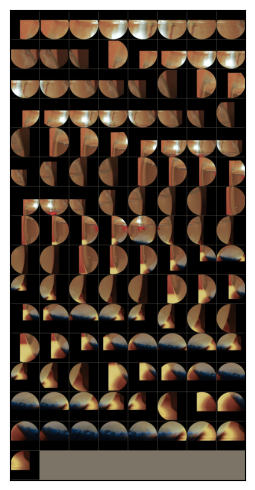

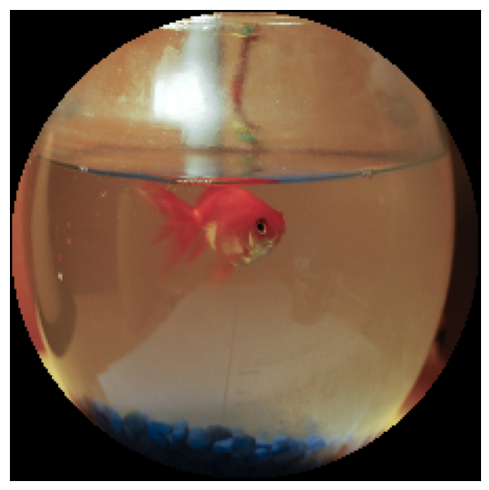

In [5]:
imshow(images.cpu())
imshow(images[arg_max_prior].cpu())